In [1]:
import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import defaultdict

DATA_DIR = pathlib.Path('../data')

# Check dataset 1 - drowsiness
print("=== Dataset 1: Drowsiness ===")
for folder in sorted((DATA_DIR / 'drowsiness').iterdir()):
    count = len(list(folder.glob('*.*')))
    print(f"{folder.name}: {count} images")

# Check dataset 2 - eye/yawn
print("\n=== Dataset 2: Eye/Yawn ===")
for split in ['train', 'test']:
    print(f"\n{split}:")
    for folder in sorted((DATA_DIR / 'eye_yawn' / split).iterdir()):
        count = len(list(folder.glob('*.*')))
        print(f"  {folder.name}: {count} images")

=== Dataset 1: Drowsiness ===
active: 4560 images
fatigue: 4560 images

=== Dataset 2: Eye/Yawn ===

train:
  Closed: 617 images
  no_yawn: 616 images
  Open: 617 images
  yawn: 617 images

test:
  Closed: 109 images
  no_yawn: 109 images
  Open: 109 images
  yawn: 106 images


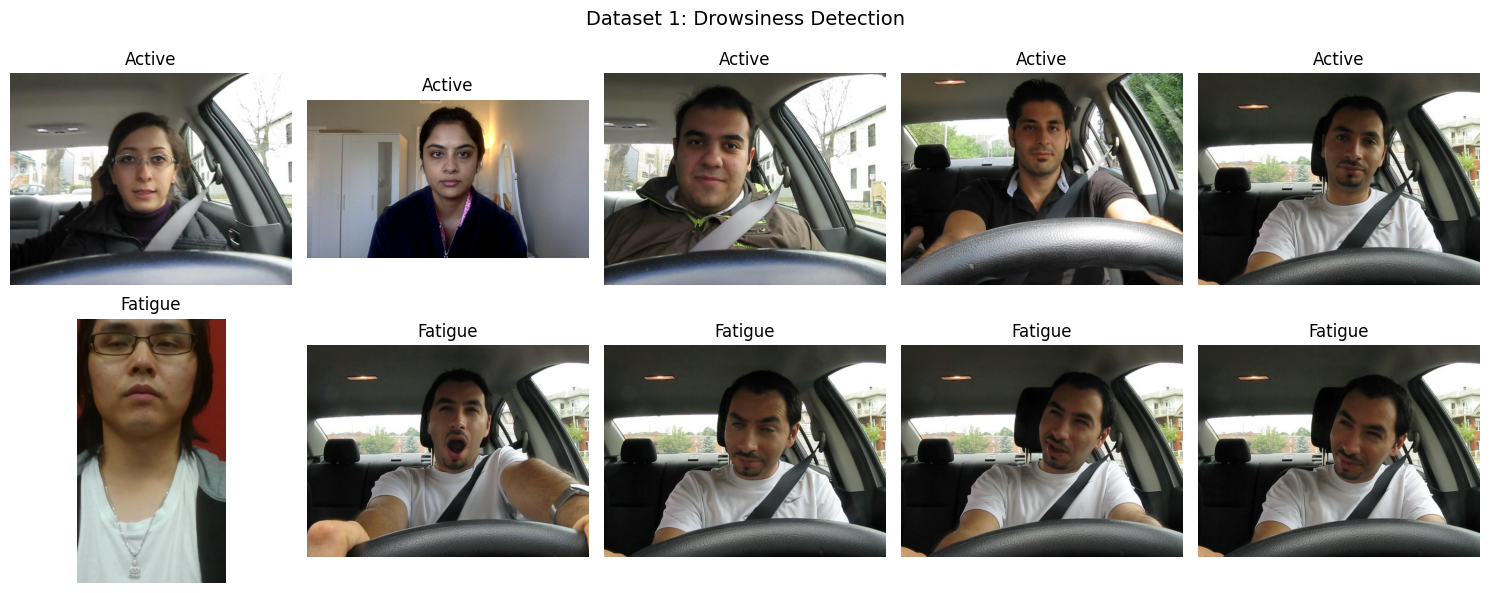

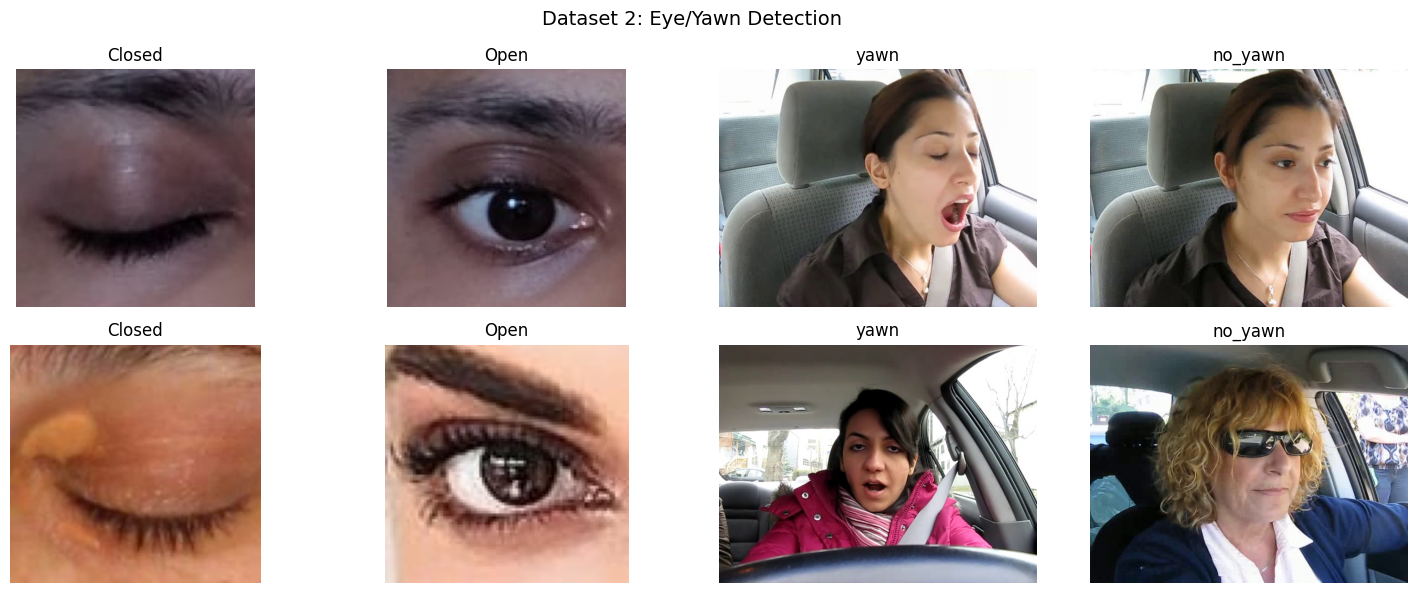

Saved sample images!


In [2]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Dataset 1: Drowsiness Detection', fontsize=14)

# Active samples
active_imgs = list((DATA_DIR / 'drowsiness' / 'active').glob('*.*'))[:5]
for i, img_path in enumerate(active_imgs):
    img = mpimg.imread(img_path)
    axes[0, i].imshow(img, cmap='gray' if len(img.shape)==2 else None)
    axes[0, i].set_title('Active')
    axes[0, i].axis('off')

# Fatigue samples
fatigue_imgs = list((DATA_DIR / 'drowsiness' / 'fatigue').glob('*.*'))[:5]
for i, img_path in enumerate(fatigue_imgs):
    img = mpimg.imread(img_path)
    axes[1, i].imshow(img, cmap='gray' if len(img.shape)==2 else None)
    axes[1, i].set_title('Fatigue')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('../outputs/drowsiness_samples.png', dpi=150, bbox_inches='tight')
plt.show()

# Dataset 2 samples
fig2, axes2 = plt.subplots(2, 4, figsize=(15, 6))
fig2.suptitle('Dataset 2: Eye/Yawn Detection', fontsize=14)

classes = ['Closed', 'Open', 'yawn', 'no_yawn']
for i, cls in enumerate(classes):
    imgs = list((DATA_DIR / 'eye_yawn' / 'train' / cls).glob('*.*'))[:2]
    for j, img_path in enumerate(imgs):
        img = mpimg.imread(img_path)
        axes2[j, i].imshow(img, cmap='gray' if len(img.shape)==2 else None)
        axes2[j, i].set_title(cls)
        axes2[j, i].axis('off')

plt.tight_layout()
plt.savefig('../outputs/eye_yawn_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved sample images!")

In [3]:
import sys
sys.path.append('../src')

from dataset import DrowsinessDataset, get_transforms
from model import get_model
from torch.utils.data import DataLoader, random_split
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

# Test Dataset 1 - Drowsiness
drowsiness_ds = DrowsinessDataset(
    '../data/drowsiness', 
    transform=get_transforms('train')
)
print(f"\nDrowsiness dataset: {len(drowsiness_ds)} images")
print(f"Classes: {drowsiness_ds.classes}")

# Test Dataset 2 - Eye/Yawn
eye_train_ds = DrowsinessDataset(
    '../data/eye_yawn/train',
    transform=get_transforms('train')
)
print(f"\nEye/Yawn train: {len(eye_train_ds)} images")
print(f"Classes: {eye_train_ds.classes}")

# Test model
model = get_model('efficientnet', num_classes=2).to(device)
x = torch.randn(4, 3, 224, 224).to(device)
out = model(x)
print(f"\nModel output shape: {out.shape}")
print("Everything working!")

Device: cuda

Drowsiness dataset: 9120 images
Classes: ['active', 'fatigue']

Eye/Yawn train: 2467 images
Classes: ['Closed', 'Open', 'no_yawn', 'yawn']
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\sharm/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 26.8MB/s]



Model output shape: torch.Size([4, 2])
Everything working!


In [4]:
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
from tqdm import tqdm

# Split drowsiness dataset 80/20
train_size = int(0.8 * len(drowsiness_ds))
val_size = len(drowsiness_ds) - train_size
train_ds, val_ds = random_split(drowsiness_ds, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

# Model
model1 = get_model('efficientnet', num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model1.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# Training
best_acc = 0
print(f"\n{'Epoch':<8} {'Train Acc':<12} {'Val Acc':<12}")
print("-" * 32)

for epoch in range(10):
    # Train
    model1.train()
    correct, total = 0, 0
    for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}'):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model1(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        correct += outputs.max(1)[1].eq(labels).sum().item()
        total += labels.size(0)
    train_acc = 100. * correct / total

    # Validate
    model1.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model1(imgs)
            correct += outputs.max(1)[1].eq(labels).sum().item()
            total += labels.size(0)
    val_acc = 100. * correct / total
    scheduler.step()

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model1.state_dict(), '../outputs/drowsiness_model.pth')

    print(f"{epoch+1:<8} {train_acc:<12.2f} {val_acc:<12.2f}")

print(f"\nBest Val Accuracy: {best_acc:.2f}%")

Train: 7296 | Val: 1824

Epoch    Train Acc    Val Acc     
--------------------------------


Epoch 1: 100%|██████████| 228/228 [02:35<00:00,  1.47it/s]


1        88.34        93.70       


Epoch 2: 100%|██████████| 228/228 [01:51<00:00,  2.04it/s]


2        93.39        95.07       


...

8        96.66        97.04       


Epoch 9: 100%|██████████| 228/228 [01:48<00:00,  2.11it/s]


9        96.83        96.98       


Epoch 10: 100%|██████████| 228/228 [01:48<00:00,  2.10it/s]


10       96.88        97.53       

Best Val Accuracy: 97.53%


In [5]:
# Model 2 - Eye/Yawn classifier (4 classes)
eye_test_ds = DrowsinessDataset(
    '../data/eye_yawn/test',
    transform=get_transforms('test')
)

eye_train_loader = DataLoader(eye_train_ds, batch_size=32, 
                              shuffle=True, num_workers=0)
eye_test_loader = DataLoader(eye_test_ds, batch_size=32, 
                             shuffle=False, num_workers=0)

print(f"Eye/Yawn Train: {len(eye_train_ds)} | Test: {len(eye_test_ds)}")
print(f"Classes: {eye_train_ds.classes}")

# Model
model2 = get_model('mobilenet', num_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

best_acc = 0
print(f"\n{'Epoch':<8} {'Train Acc':<12} {'Test Acc':<12}")
print("-" * 32)

for epoch in range(10):
    # Train
    model2.train()
    correct, total = 0, 0
    for imgs, labels in tqdm(eye_train_loader, desc=f'Epoch {epoch+1}'):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model2(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        correct += outputs.max(1)[1].eq(labels).sum().item()
        total += labels.size(0)
    train_acc = 100. * correct / total

    # Test
    model2.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in eye_test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model2(imgs)
            correct += outputs.max(1)[1].eq(labels).sum().item()
            total += labels.size(0)
    test_acc = 100. * correct / total
    scheduler.step()

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model2.state_dict(), '../outputs/eye_yawn_model.pth')

    print(f"{epoch+1:<8} {train_acc:<12.2f} {test_acc:<12.2f}")

print(f"\nBest Test Accuracy: {best_acc:.2f}%")

Eye/Yawn Train: 2467 | Test: 433
Classes: ['Closed', 'Open', 'no_yawn', 'yawn']
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\sharm/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 10.9MB/s]



Epoch    Train Acc    Test Acc    
--------------------------------


Epoch 1: 100%|██████████| 78/78 [00:27<00:00,  2.86it/s]


1        90.19        96.07       


...

8        99.72        99.54       


Epoch 9: 100%|██████████| 78/78 [00:11<00:00,  6.74it/s]


9        99.68        99.54       


Epoch 10: 100%|██████████| 78/78 [00:11<00:00,  6.71it/s]


10       99.76        99.54       

Best Test Accuracy: 99.54%


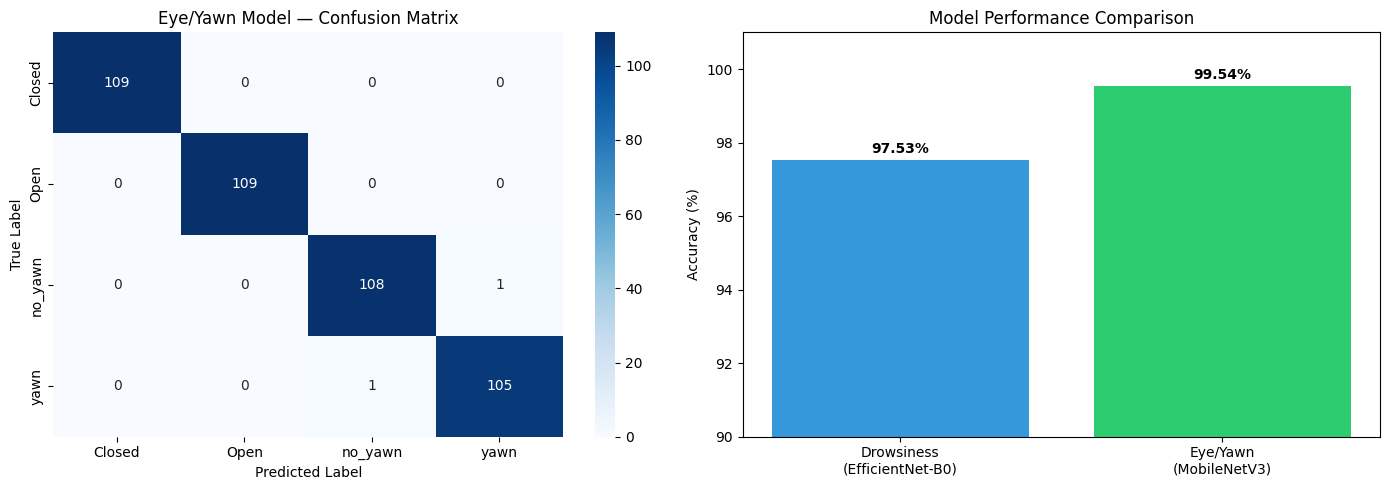


Eye/Yawn Classification Report:
              precision    recall  f1-score   support

      Closed       1.00      1.00      1.00       109
        Open       1.00      1.00      1.00       109
     no_yawn       0.99      0.99      0.99       109
        yawn       0.99      0.99      0.99       106

    accuracy                           1.00       433
   macro avg       1.00      1.00      1.00       433
weighted avg       1.00      1.00      1.00       433



In [6]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Evaluate Model 2 with confusion matrix
model2.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in eye_test_loader:
        imgs = imgs.to(device)
        outputs = model2(imgs)
        preds = outputs.max(1)[1].cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
classes = eye_train_ds.classes

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title('Eye/Yawn Model — Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot accuracy comparison
models = ['Drowsiness\n(EfficientNet-B0)', 'Eye/Yawn\n(MobileNetV3)']
accuracies = [97.53, 99.54]
colors = ['#3498db', '#2ecc71']
bars = axes[1].bar(models, accuracies, color=colors)
axes[1].set_ylim(90, 101)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Model Performance Comparison')
for bar, acc in zip(bars, accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2, 
                bar.get_height() + 0.1,
                f'{acc}%', ha='center', va='bottom', 
                fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/model_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification report
print("\nEye/Yawn Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))